## Setup

In this section, I import the required PyTorch and torchvision libraries, set the training device, and fix the random seed for reproducibility.

This lab compares three different approaches for image classification on the Flowers-102 dataset: training a CNN from scratch, using a pretrained ResNet18 as a frozen feature extractor, and fine-tuning part of a pretrained model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)

Device: cuda


## Image Transformations and ImageNet Preprocessing

The images are resized and cropped to `224 × 224`, which is the standard input size for many pretrained ImageNet models such as ResNet18.

For the training set, I use random cropping, horizontal flipping, and color jittering to apply data augmentation. These transformations help reduce overfitting by showing the model slightly different versions of the same image during training.

For validation and test data, I use deterministic transformations: resize, center crop, tensor conversion, and normalization. Random augmentation is not used for validation or test data because evaluation should be stable and reproducible.

The ImageNet mean and standard deviation are used for normalization because pretrained ResNet models were originally trained with this preprocessing.

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

## Loading the Flowers-102 Dataset

The Flowers-102 dataset is loaded using its official train, validation, and test splits.

The dataset contains **102 flower classes**, but the training split is relatively small. In this run, the dataset sizes are:

- Train: **1020 images**
- Validation: **1020 images**
- Test: **6149 images**

This split is useful for transfer learning experiments because the training set is small, making it difficult for a randomly initialized CNN to learn strong visual features from scratch.

In [3]:
train_set = datasets.Flowers102(
    root="./data",
    split="train",
    download=True,
    transform=train_tf
)

val_set = datasets.Flowers102(
    root="./data",
    split="val",
    download=True,
    transform=val_tf
)

test_set = datasets.Flowers102(
    root="./data",
    split="test",
    download=True,
    transform=val_tf
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print("Train size:", len(train_set))
print("Val size:", len(val_set))
print("Test size:", len(test_set))

Train size: 1020
Val size: 1020
Test size: 6149


## Batch Shape Check

Before training, I check one batch from the training DataLoader.

Each image batch has shape `(batch_size, 3, 224, 224)`, meaning the model receives RGB images with 3 color channels and spatial size `224 × 224`.

The label batch has shape `(batch_size)`, where each label is an integer representing one of the 102 flower classes.

In [4]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Min label:", labels.min().item())
print("Max label:", labels.max().item())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Min label: 3
Max label: 97


## Training and Evaluation Helper Functions

I define reusable helper functions for training, evaluation, parameter counting, and plotting.

The training function sets the model to training mode, performs forward passes, computes the loss, backpropagates gradients, and updates the model weights.

The evaluation function sets the model to evaluation mode and computes loss and accuracy without updating the weights. This is used for validation and test evaluation.

The plotting function visualizes training and validation loss and accuracy curves, which helps diagnose learning behavior and overfitting.

In [5]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / total
    acc = correct / total
    
    return avg_loss, acc

In [7]:
def evaluate(model, loader, criterion):
    model.eval()
    
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / total
    acc = correct / total
    
    return avg_loss, acc

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    best_val_acc = 0
    
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )
        
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )
        
        if scheduler is not None:
            scheduler.step()
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        best_val_acc = max(best_val_acc, val_acc)
        
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )
    
    total_time = time.time() - start_time
    
    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
        "time": total_time
    }
    
    return history

In [9]:
def plot_history(history, title):
    epochs = range(1, len(history["train_losses"]) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs, history["train_losses"], label="Train Loss")
    axes[0].plot(epochs, history["val_losses"], label="Validation Loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    axes[1].plot(epochs, history["train_accs"], label="Train Accuracy")
    axes[1].plot(epochs, history["val_accs"], label="Validation Accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    
    plt.show()

## Task 1 — From-Scratch CNN Baseline

In this task, I train a small CNN from scratch on the Flowers-102 dataset.

The model starts with random weights, meaning it has no pretrained visual knowledge. It must learn low-level features such as edges and textures, as well as higher-level flower patterns, directly from the small training set.

The CNN uses convolutional layers, batch normalization, ReLU activations, max pooling, and a final classifier that outputs predictions for 102 flower classes.

In [10]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model Parameter Count

I count both the total number of parameters and the trainable parameters in the from-scratch CNN.

Since this model is trained from scratch, all parameters are trainable. This means every convolutional layer and classifier layer will be updated during training.

The model is designed to stay within the expected range of roughly 1–3 million parameters for this baseline experiment.

In [11]:
scratch_model = SmallCNN(num_classes=102).to(device)

scratch_total_params, scratch_trainable_params = count_parameters(scratch_model)

print("Total parameters:", scratch_total_params)
print("Trainable parameters:", scratch_trainable_params)

Total parameters: 3129958
Trainable parameters: 3129958


## Training the From-Scratch CNN

The from-scratch CNN is trained for 15 epochs using Adam with a learning rate of `1e-3`.

A cosine annealing learning-rate scheduler is used to gradually reduce the learning rate during training. This can help the model make larger updates early in training and smaller, more stable updates later.

During each epoch, I track training loss, training accuracy, validation loss, and validation accuracy.

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    scratch_model.parameters(),
    lr=1e-3
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

scratch_history = train_model(
    model=scratch_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=15
)

Epoch [1/15] Train Loss: 4.7500 Train Acc: 0.0255 Val Loss: 4.2524 Val Acc: 0.0539
Epoch [2/15] Train Loss: 4.1821 Train Acc: 0.0608 Val Loss: 3.8148 Val Acc: 0.0755
Epoch [3/15] Train Loss: 3.9014 Train Acc: 0.0725 Val Loss: 3.8371 Val Acc: 0.0784
Epoch [4/15] Train Loss: 3.7330 Train Acc: 0.1108 Val Loss: 3.4261 Val Acc: 0.1775
Epoch [5/15] Train Loss: 3.4455 Train Acc: 0.1402 Val Loss: 3.3252 Val Acc: 0.1667
Epoch [6/15] Train Loss: 3.3555 Train Acc: 0.1549 Val Loss: 3.3043 Val Acc: 0.2010
Epoch [7/15] Train Loss: 3.1943 Train Acc: 0.1765 Val Loss: 3.1319 Val Acc: 0.2088
Epoch [8/15] Train Loss: 3.0254 Train Acc: 0.2137 Val Loss: 3.0659 Val Acc: 0.2363
Epoch [9/15] Train Loss: 2.9273 Train Acc: 0.2422 Val Loss: 2.9858 Val Acc: 0.2373
Epoch [10/15] Train Loss: 2.7794 Train Acc: 0.2578 Val Loss: 2.9475 Val Acc: 0.2696
Epoch [11/15] Train Loss: 2.8078 Train Acc: 0.2676 Val Loss: 2.8725 Val Acc: 0.2814
Epoch [12/15] Train Loss: 2.6171 Train Acc: 0.2980 Val Loss: 2.8382 Val Acc: 0.2902
E

## From-Scratch CNN Learning Curves

The learning curves show that the from-scratch CNN gradually learned useful patterns from the Flowers-102 dataset. Both training and validation loss decreased over time, which indicates that the model was improving during training.

Validation accuracy increased from about **5.29%** in the first epoch to a best value of **30.59%**. However, the final test accuracy was only **26.74%**, showing that the model still struggled to generalize well to unseen images.

This result is expected because the model was trained from random initialization on only **1020 training images** across **102 classes**. With such limited data, learning strong visual features from scratch is difficult, which makes this a useful baseline for comparing against transfer learning.

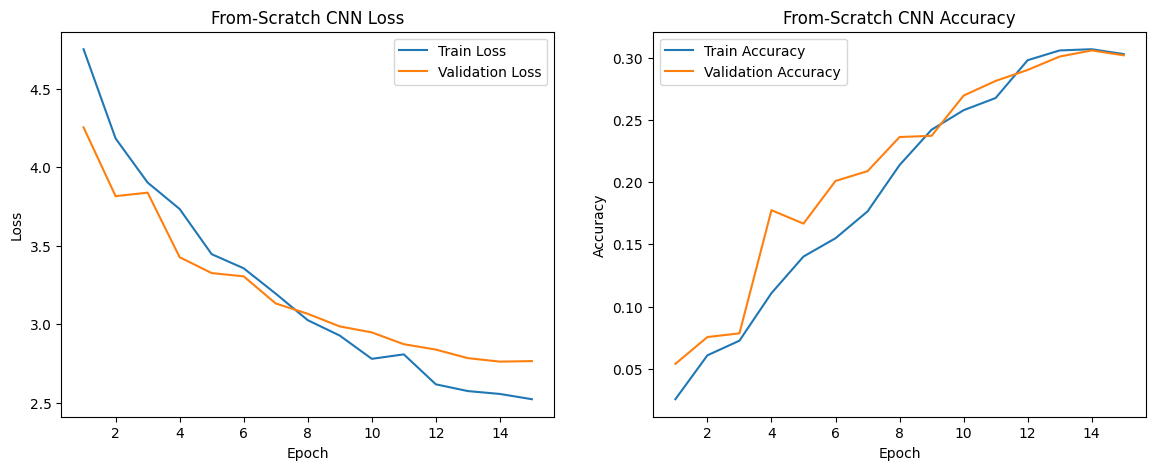

In [13]:
plot_history(scratch_history, "From-Scratch CNN")

In [14]:
scratch_test_loss, scratch_test_acc = evaluate(
    scratch_model,
    test_loader,
    criterion
)

scratch_best_val_acc = scratch_history["best_val_acc"]
scratch_train_time = scratch_history["time"]

print(f"From-scratch best validation accuracy: {scratch_best_val_acc:.4f}")
print(f"From-scratch test accuracy: {scratch_test_acc:.4f}")
print(f"From-scratch training time: {scratch_train_time:.2f} seconds")

From-scratch best validation accuracy: 0.3059
From-scratch test accuracy: 0.2674
From-scratch training time: 210.90 seconds


## Task 1 — From-Scratch Baseline Interpretation

The from-scratch CNN learned some useful visual patterns from the Flowers-102 dataset, but its performance remained limited.

Training loss decreased from **4.7500** to **2.5223**, and validation loss decreased from **4.2524** to **2.7650**. Training accuracy improved from **2.55%** to **30.29%**, while validation accuracy reached a best value of **30.59%**.

The final test accuracy was **26.74%**, which shows that the model generalized only moderately to unseen images. This result is expected because the model started from random initialization and had to learn all visual features from only **1020 training images** across **102 classes**.

Overall, this from-scratch CNN provides a useful baseline, but the relatively low validation and test accuracy show that training from scratch is not ideal for this small dataset.

# Task 2 — Feature Extraction with Pretrained ResNet18

In this task, I use a pretrained ResNet18 model as a fixed feature extractor.

The convolutional backbone of ResNet18 was pretrained on ImageNet, so it already learned general visual features such as edges, textures, shapes, and object parts. I freeze all pretrained layers and replace only the final classification layer with a new linear layer for the 102 flower classes.

Only the new classification head is trained, while the pretrained backbone remains unchanged.

In [15]:
feature_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

## Freezing the Backbone and Replacing the Classifier

First, I load a pretrained ResNet18 model using ImageNet weights. Then I freeze all of its parameters by setting `requires_grad=False`.

Freezing means that these pretrained weights will not be updated during training. The model will use the pretrained convolutional layers only to extract image features.

The original ResNet18 classifier predicts 1000 ImageNet classes, so I replace the final `fc` layer with a new linear layer that outputs 102 flower classes.

In [16]:
for p in feature_model.parameters():
    p.requires_grad = False

## Trainable Parameter Check

After freezing the backbone and replacing the classifier, I verify which parameters still require gradients.

Only the new final classification layer should be trainable. This confirms that the model is being used as a feature extractor and that the pretrained backbone is not being updated.

This setup greatly reduces the number of trainable parameters compared with training the full model.

In [17]:
num_features = feature_model.fc.in_features
feature_model.fc = nn.Linear(num_features, 102)
feature_model = feature_model.to(device)

In [18]:
feature_total_params, feature_trainable_params = count_parameters(feature_model)

print("Total parameters:", feature_total_params)
print("Trainable parameters:", feature_trainable_params)

for name, param in feature_model.named_parameters():
    if param.requires_grad:
        print("Trainable:", name)

Total parameters: 11228838
Trainable parameters: 52326
Trainable: fc.weight
Trainable: fc.bias


## Training the Feature Extraction Model

The feature extraction model is trained for 15 epochs using Adam with a learning rate of `1e-3`.

The optimizer is applied only to parameters where `requires_grad=True`, meaning only the new classification head is updated. The pretrained ResNet18 backbone remains frozen during the entire training process.

This makes training faster and more data-efficient because the model does not need to learn low-level visual features from scratch.

In [19]:
criterion = nn.CrossEntropyLoss()

trainable_params = filter(lambda p: p.requires_grad, feature_model.parameters())

optimizer = optim.Adam(
    trainable_params,
    lr=1e-3
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

## Training the Feature Extraction Model

The feature extraction model is trained for 15 epochs using Adam with a learning rate of `1e-3`.

The optimizer is applied only to parameters where `requires_grad=True`, meaning only the new classification head is updated. The pretrained ResNet18 backbone remains frozen during the entire training process.

This makes training faster and more data-efficient because the model does not need to learn low-level visual features from scratch.

In [20]:
feature_history = train_model(
    model=feature_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=15
)

Epoch [1/15] Train Loss: 4.7045 Train Acc: 0.0441 Val Loss: 3.8853 Val Acc: 0.1676
Epoch [2/15] Train Loss: 3.3625 Train Acc: 0.3922 Val Loss: 2.9660 Val Acc: 0.5059
Epoch [3/15] Train Loss: 2.4822 Train Acc: 0.6873 Val Loss: 2.3137 Val Acc: 0.6500
Epoch [4/15] Train Loss: 1.8154 Train Acc: 0.8176 Val Loss: 1.8930 Val Acc: 0.7294
Epoch [5/15] Train Loss: 1.4205 Train Acc: 0.8931 Val Loss: 1.6236 Val Acc: 0.7784
Epoch [6/15] Train Loss: 1.1517 Train Acc: 0.9167 Val Loss: 1.4277 Val Acc: 0.7980
Epoch [7/15] Train Loss: 0.9522 Train Acc: 0.9588 Val Loss: 1.3039 Val Acc: 0.8176
Epoch [8/15] Train Loss: 0.8096 Train Acc: 0.9608 Val Loss: 1.2231 Val Acc: 0.8245
Epoch [9/15] Train Loss: 0.7285 Train Acc: 0.9706 Val Loss: 1.1754 Val Acc: 0.8265
Epoch [10/15] Train Loss: 0.6792 Train Acc: 0.9745 Val Loss: 1.1292 Val Acc: 0.8225
Epoch [11/15] Train Loss: 0.6165 Train Acc: 0.9765 Val Loss: 1.1137 Val Acc: 0.8373
Epoch [12/15] Train Loss: 0.6007 Train Acc: 0.9794 Val Loss: 1.0813 Val Acc: 0.8382
E

In [21]:
print("feature_model exists:", "feature_model" in globals())
print("feature_history exists:", "feature_history" in globals())
print("feature_test_acc exists:", "feature_test_acc" in globals())

feature_model exists: True
feature_history exists: True
feature_test_acc exists: False


## Feature Extraction Learning Curves

The feature extraction model learned much faster than the from-scratch CNN.

Training accuracy increased from **4.41%** to **98.73%**, while validation accuracy improved from **16.76%** to a best value of **83.82%**. The validation loss decreased steadily for most of training, showing that the pretrained ResNet features transferred well to the Flowers-102 classification task.

There is a visible gap between training accuracy and validation accuracy, which suggests some overfitting in the new classifier head. However, the validation and test performance are still much stronger than the from-scratch baseline.

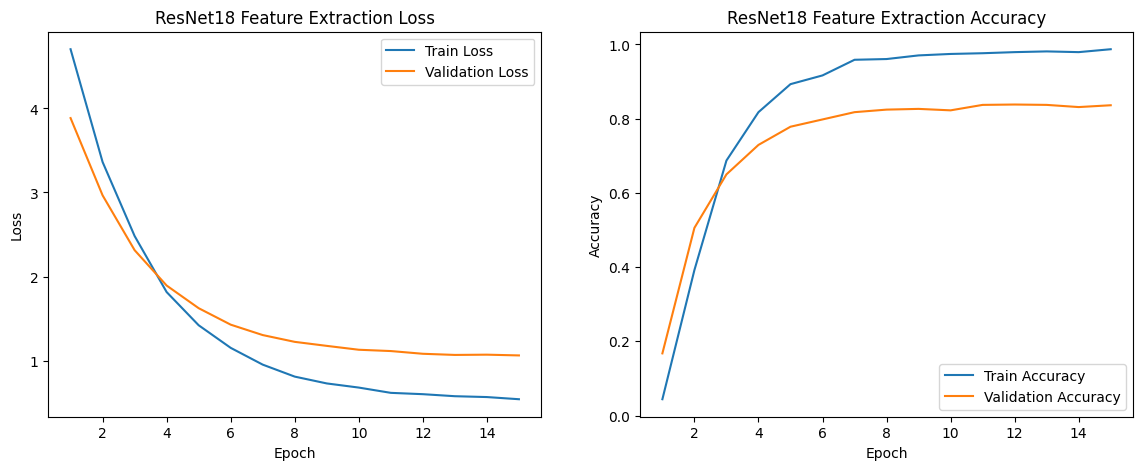

In [22]:
plot_history(feature_history, "ResNet18 Feature Extraction")

In [23]:
feature_test_loss, feature_test_acc = evaluate(
    feature_model,
    test_loader,
    criterion
)

feature_best_val_acc = feature_history["best_val_acc"]
feature_train_time = feature_history["time"]

print(f"Feature extraction best validation accuracy: {feature_best_val_acc:.4f}")
print(f"Feature extraction test accuracy: {feature_test_acc:.4f}")
print(f"Feature extraction training time: {feature_train_time:.2f} seconds")

Feature extraction best validation accuracy: 0.8382
Feature extraction test accuracy: 0.8182
Feature extraction training time: 193.84 seconds


## Task 2 — Feature Extraction Interpretation

The pretrained ResNet18 feature extraction approach performed much better than the from-scratch CNN.

In this setup, the ResNet18 backbone was frozen and only the final classification layer was trained for the 102 flower classes. The trainable parameter check confirmed that only `fc.weight` and `fc.bias` were updated during training.

The best validation accuracy reached **83.82%**, and the final test accuracy was **81.82%**. This is a large improvement over the from-scratch baseline, which achieved only **30.59%** best validation accuracy and **26.74%** test accuracy.

This result shows the value of transfer learning on small image datasets. Instead of learning all visual features from only **1020 training images**, the model reused general visual representations learned from ImageNet and only trained a new classifier head for the flower classes.

Although training accuracy became very high, validation and test accuracy also remained strong, showing that the pretrained backbone helped the model generalize much better than the randomly initialized CNN.

# Task 3 — Fine-Tuning the Last Block

In this task, I continue training the pretrained ResNet18 model from Task 2.

In Task 2, the entire ResNet18 backbone was frozen and only the final classification head was trained. Now, I unfreeze the last residual block (`layer4`) together with the final classifier (`fc`).

This allows the model to slightly adapt the higher-level ImageNet features to the Flowers-102 dataset, while keeping the earlier low-level feature extractors frozen.

In [24]:
# Make sure the rest of the backbone stays frozen
for p in feature_model.parameters():
    p.requires_grad = False

# Unfreeze the last residual block
for p in feature_model.layer4.parameters():
    p.requires_grad = True

# Keep the final classifier trainable
for p in feature_model.fc.parameters():
    p.requires_grad = True

## Unfreezing Selected Layers

I first freeze all parameters again to make sure the model is in a clean state. Then I unfreeze only `layer4` and `fc`.

The earlier layers of ResNet18 usually learn general low-level visual patterns such as edges, colors, and simple textures. These features transfer well across image datasets, so I leave them frozen.

The last block (`layer4`) learns more task-specific high-level features. By unfreezing it, the model can adapt these higher-level representations to flower classification.

In [25]:
fine_total_params, fine_trainable_params = count_parameters(feature_model)

print("Total parameters:", fine_total_params)
print("Trainable parameters:", fine_trainable_params)

print("\nTrainable layers:")
for name, param in feature_model.named_parameters():
    if param.requires_grad:
        print(name)

Total parameters: 11228838
Trainable parameters: 8446054

Trainable layers:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


## Trainable Parameter Check

After unfreezing `layer4` and `fc`, I verify which parameters require gradients.

Only the parameters inside `layer4` and the final classifier should be trainable. This confirms that most of the pretrained ResNet18 backbone remains frozen, while the last block and the classification head can continue learning.

This setup is a middle ground between feature extraction and full fine-tuning.

In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {"params": feature_model.layer4.parameters(), "lr": 1e-5},
    {"params": feature_model.fc.parameters(), "lr": 1e-3},
])

## Discriminative Learning Rates

I use different learning rates for different parts of the model.

The last ResNet block (`layer4`) uses a small learning rate of `1e-5` because it already contains useful pretrained ImageNet features. I do not want to change these weights too aggressively.

The final classification layer (`fc`) uses a larger learning rate of `1e-3` because it was newly created for the 102 flower classes and needs to learn faster.

In [27]:
fine_tune_history = train_model(
    model=feature_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    epochs=10
)

Epoch [1/10] Train Loss: 0.6549 Train Acc: 0.9363 Val Loss: 0.9491 Val Acc: 0.8235
Epoch [2/10] Train Loss: 0.3761 Train Acc: 0.9755 Val Loss: 0.7964 Val Acc: 0.8471
Epoch [3/10] Train Loss: 0.2770 Train Acc: 0.9922 Val Loss: 0.7233 Val Acc: 0.8402
Epoch [4/10] Train Loss: 0.1976 Train Acc: 0.9951 Val Loss: 0.6507 Val Acc: 0.8608
Epoch [5/10] Train Loss: 0.1497 Train Acc: 0.9941 Val Loss: 0.6033 Val Acc: 0.8647
Epoch [6/10] Train Loss: 0.1214 Train Acc: 0.9961 Val Loss: 0.5795 Val Acc: 0.8667
Epoch [7/10] Train Loss: 0.1034 Train Acc: 0.9980 Val Loss: 0.5471 Val Acc: 0.8706
Epoch [8/10] Train Loss: 0.0824 Train Acc: 0.9980 Val Loss: 0.5276 Val Acc: 0.8775
Epoch [9/10] Train Loss: 0.0653 Train Acc: 1.0000 Val Loss: 0.5132 Val Acc: 0.8824
Epoch [10/10] Train Loss: 0.0612 Train Acc: 0.9990 Val Loss: 0.5104 Val Acc: 0.8784


## Fine-Tuning Training

The model is trained for an additional 10 epochs.

During this stage, only `layer4` and `fc` are updated. The rest of the ResNet18 backbone remains frozen.

The goal is to improve performance beyond feature extraction by allowing the highest-level visual features to adapt slightly to the Flowers-102 dataset.

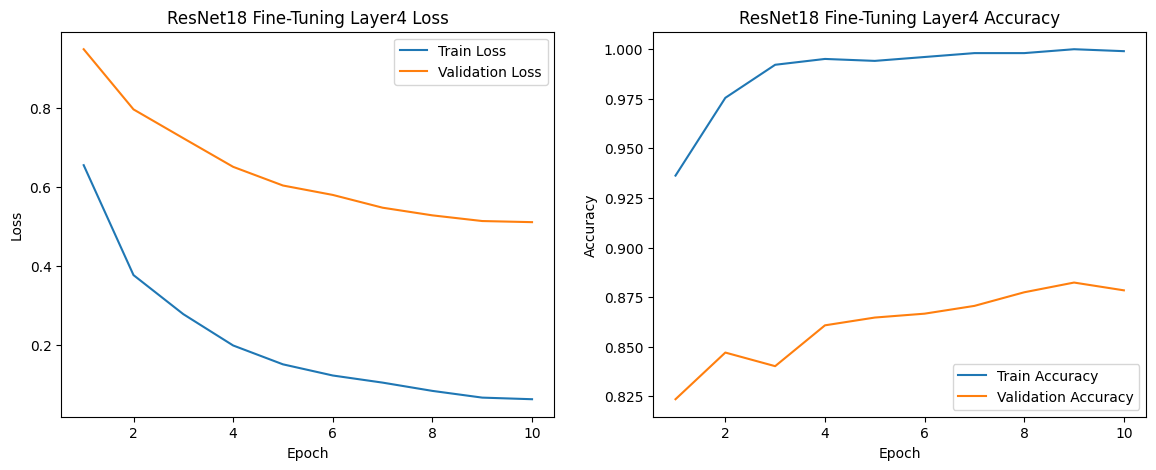

In [28]:
plot_history(fine_tune_history, "ResNet18 Fine-Tuning Layer4")

## Fine-Tuning Learning Curves

The fine-tuning curves show that unfreezing `layer4` helped the model continue improving after feature extraction.

Training accuracy quickly approached nearly perfect performance, reaching **99.90%** by the final epoch. Validation accuracy also improved and reached a best value of **88.24%**, showing that fine-tuning improved generalization rather than only memorizing the training set.

Validation loss decreased from **0.9491** to **0.5104**, which confirms that the model became more confident and accurate on unseen validation images. There is still a gap between training and validation accuracy, but the validation and test performance are both stronger than feature extraction alone.

In [29]:
fine_test_loss, fine_test_acc = evaluate(
    feature_model,
    test_loader,
    criterion
)

fine_best_val_acc = fine_tune_history["best_val_acc"]
fine_tune_time = fine_tune_history["time"]

# Since fine-tuning continues from the feature extraction model,
# total time includes Task 2 training time + Task 3 fine-tuning time.
fine_total_training_time = feature_train_time + fine_tune_time

print(f"Fine-tuning best validation accuracy: {fine_best_val_acc:.4f}")
print(f"Fine-tuning test accuracy: {fine_test_acc:.4f}")
print(f"Fine-tuning additional training time: {fine_tune_time:.2f} seconds")
print(f"Fine-tuning total training time: {fine_total_training_time:.2f} seconds")

Fine-tuning best validation accuracy: 0.8824
Fine-tuning test accuracy: 0.8639
Fine-tuning additional training time: 126.09 seconds
Fine-tuning total training time: 319.92 seconds


## Task 3 — Fine-Tuning Interpretation

Fine-tuning improved the pretrained ResNet18 model beyond feature extraction.

In this stage, I unfroze `layer4`, the last residual block of ResNet18, while keeping the earlier layers frozen. The final classification layer remained trainable. This allowed the model to adapt higher-level ImageNet features to the Flowers-102 dataset without changing the entire pretrained backbone.

The model was trained for an additional **10 epochs** using discriminative learning rates: `1e-5` for `layer4` and `1e-3` for the final classifier. The smaller learning rate for `layer4` helped preserve useful pretrained features, while the larger learning rate allowed the classifier head to keep adapting quickly.

Fine-tuning reached a best validation accuracy of **88.24%** and a test accuracy of **86.39%**. This improved over feature extraction, which achieved **83.82%** best validation accuracy and **81.82%** test accuracy.

Overall, unfreezing the last block helped the model learn more flower-specific high-level features while still benefiting from pretrained ImageNet representations.

In [30]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Approach": [
        "From scratch (Task 1)",
        "Feature extraction (Task 2)",
        "Fine-tune last block (Task 3)"
    ],
    "Trainable params": [
        scratch_trainable_params,
        feature_trainable_params,
        fine_trainable_params
    ],
    "Best val acc": [
        scratch_best_val_acc,
        feature_best_val_acc,
        fine_best_val_acc
    ],
    "Test acc": [
        scratch_test_acc,
        feature_test_acc,
        fine_test_acc
    ],
    "Total training time": [
        scratch_train_time,
        feature_train_time,
        fine_total_training_time
    ]
})

comparison_df

,Approach,Trainable params,Best val acc,Test acc,Total training time
0,From scratch (Task 1),3129958,0.305882,0.267361,210.901655
1,Feature extraction (Task 2),52326,0.838235,0.818182,193.836107
2,Fine-tune last block (Task 3),8446054,0.882353,0.863880,319.923892


## Final Comparison and Recommendation

The results clearly show that transfer learning provided a major improvement over training from scratch. The from-scratch CNN achieved only **30.59%** best validation accuracy and **26.74%** test accuracy, while feature extraction with pretrained ResNet18 reached **83.82%** best validation accuracy and **81.82%** test accuracy.

This large improvement happened because the pretrained ResNet18 backbone already had strong general visual features learned from ImageNet. Since Flowers-102 has only **1020 training images** across **102 classes**, learning useful visual features from random initialization was difficult for the from-scratch CNN.

Fine-tuning the last block improved the result even further. After unfreezing `layer4`, the model reached **88.24%** best validation accuracy and **86.39%** test accuracy, which was better than feature extraction alone.

The fine-tuned model required many more trainable parameters (**8,446,054**) and the longest total training time (**319.92 seconds**), but it achieved the best overall performance. Feature extraction was much more efficient, using only **52,326** trainable parameters while still reaching strong accuracy.

For tomorrow's cat-detection assessment, I would recommend starting from a pretrained model instead of training from scratch. If time or compute is limited, feature extraction is a strong first choice; if the goal is maximum accuracy and there is enough time to train, fine-tuning the last block is the best option.